In [ ]:
import torch
from torch import nn
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
# Checking out MNIST dataset
train_dataset_pretransform = datasets.MNIST(root='data',
                                            train=True,
                                            download=True)

In [ ]:
# Print string representation of dataset object defined in __str__
print(train_dataset_pretransform)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train


In [ ]:
# Availablie dataset attributes and methods
print(dir(train_dataset_pretransform))

['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_check_exists', '_check_legacy_exist', '_format_transform_repr', '_load_data', '_load_legacy_data', '_repr_indent', 'class_to_idx', 'classes', 'data', 'download', 'extra_repr', 'mirrors', 'processed_folder', 'raw_folder', 'resources', 'root', 'target_transform', 'targets', 'test_data', 'test_file', 'test_labels', 'train', 'train_data', 'train_labels', 'training_file', 'transform', 'transforms']


In [ ]:
# dataset implements __len__ -> length can be retrieved using: len()
# Get dataset length -> Calls __len__
len(train_dataset_pretransform)

60000

In [ ]:
# dataset implements __getitem__ -> items can be retrieved using list indexing: dataset[index]
# Access first (img, label) pair -> Calls __getitem__
# image is of type PIL.Image.Image
img_pretr, label_pretr = train_dataset_pretransform[0]
type(img_pretr), type(label_pretr)

(PIL.Image.Image, int)

In [ ]:
# All image data
train_dataset_pretransform.data.shape

torch.Size([60000, 28, 28])

In [ ]:
# All labels
train_dataset_pretransform.targets.shape

torch.Size([60000])

In [ ]:
# All class names
train_dataset_pretransform.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [ ]:
# Mapping from label name to index
train_dataset_pretransform.class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [ ]:
# Define transform for dataset
transforms = v2.Compose([
    v2.Resize((32,32)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.1307,), std=(0.3081,))
])

In [ ]:
# Download train and test dataset with transform
train_dataset = datasets.MNIST(root='data',
                               train=True,
                               transform=transforms,
                               download=True)
test_dataset = datasets.MNIST(root='data',
                              train=False,
                              transform=transforms,
                              download=True)

In [ ]:
# Show string representation
print(train_dataset)
print(test_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
                 Resize(size=[32, 32], interpolation=InterpolationMode.BILINEAR, antialias=True)
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.1307], std=[0.3081], inplace=False)
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
                 Resize(size=[32, 32], interpolation=InterpolationMode.BILINEAR, antialias=True)
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.1307], std=[0.3081], inplace=False)
           )


In [ ]:
# Access first pair
img, label = train_dataset[0]
type(img), type(label)

(torchvision.tv_tensors._image.Image, int)

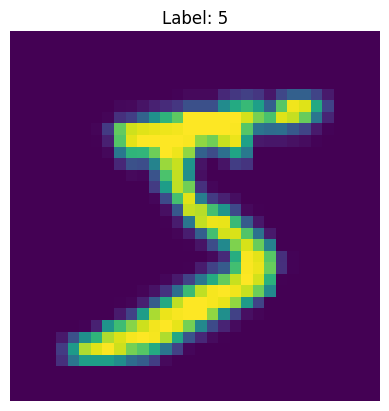

In [ ]:
# Check out first sample of dataset
plt.imshow(img.squeeze()) # adds an image to the plot
plt.title(f'Label: {label}')
plt.axis("off")
plt.show() # makes the plot appear on your screen

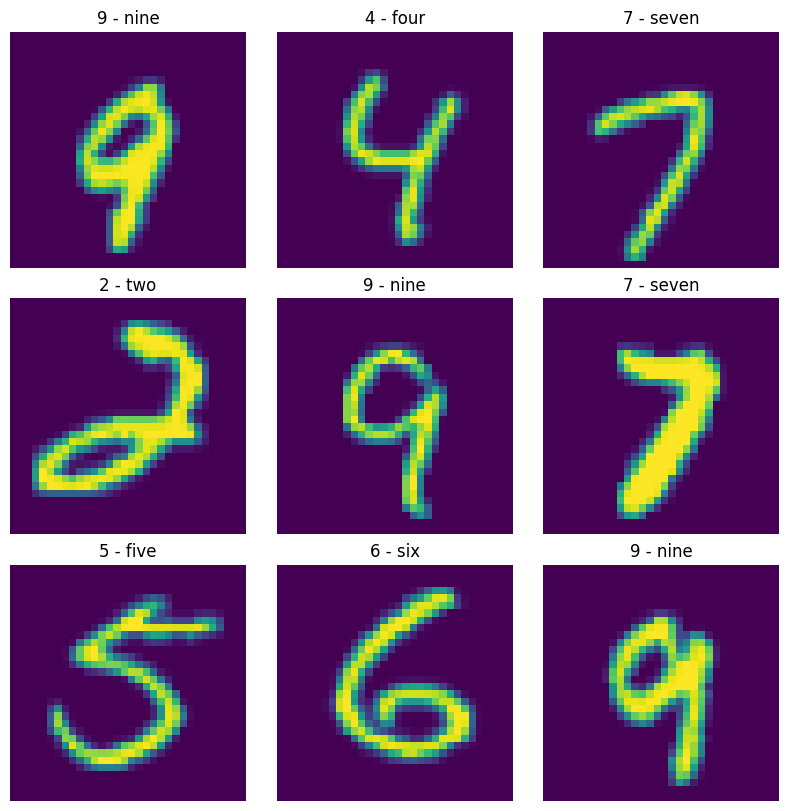

In [ ]:
random.seed(42)
ncols, nrows = 3, 3
fig, axs = plt.subplots(ncols=ncols, nrows=nrows,
                        figsize=(8, 8),
                        layout="constrained")
for row in range(nrows):
  for col in range(ncols):
    ax = axs[row, col]
    #sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    sample_idx = random.randint(0, len(train_dataset)-1)
    img, label = train_dataset[sample_idx]
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")
    ax.imshow(img.squeeze())
plt.show()

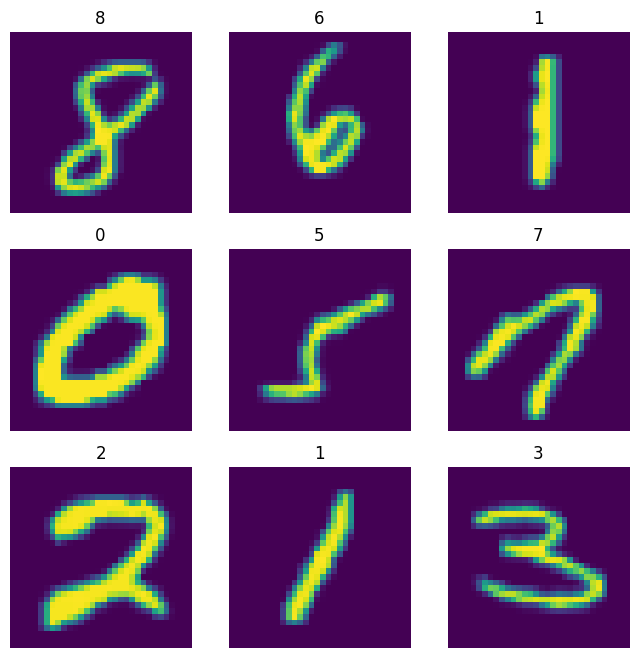

In [ ]:
# Show multiple samples
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
  img, label = train_dataset[sample_idx]
  figure.add_subplot(cols, rows, i)
  plt.title(label)
  plt.axis("off")
  plt.imshow(img.squeeze())
plt.show()

In [ ]:
# Preparing data with Dataloader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=BATCH_SIZE,
                             shuffle=True)

In [ ]:
# dataloader implements __iter__ -> is an iterator-like object
# dataloader can't be indexed -> instead you iterate over it using for-loop or next()
# but you can retrieve number of batches using len()
# Accessing first batch
batch = next(iter(train_dataloader))
batch_images, batch_labels = batch
batch_images.shape, batch_labels.shape, len(train_dataloader)

(torch.Size([32, 1, 32, 32]), torch.Size([32]), 1875)

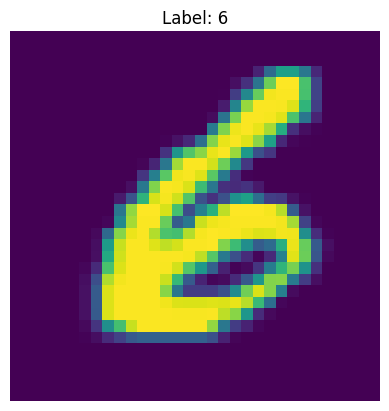

In [ ]:
# Check our first sample of first batch
INDEX = 0
plt.imshow(batch_images[INDEX].squeeze())
plt.title(f"Label: {batch_labels[INDEX]}")
plt.axis("off")
plt.show()

In [ ]:
class LeNet5(nn.Module):
  def __init__(self):
    super().__init__()
    ### input 32x32 image
    self.C1 = nn.Conv2d(in_channels=1,
                        out_channels=6,
                        kernel_size=5,
                        stride=1,
                        padding=0,
                        padding_mode='zeros')
    self.S2 = nn.AvgPool2d(kernel_size=2,
                           stride=2,
                           padding=0)
    self.C3 = nn.Conv2d(in_channels=6,
                        out_channels=16,
                        kernel_size=5,
                        stride=1,
                        padding=0,
                        padding_mode='zeros')
    self.S4 = nn.AvgPool2d(kernel_size=2,
                           stride=2,
                           padding=0)
    self.C5 = nn.Conv2d(in_channels=16,
                        out_channels=120,
                        kernel_size=5,
                        stride=1,
                        padding=0,
                        padding_mode='zeros')
    self.F6 = nn.Sequential(nn.Flatten(start_dim=1),
                            nn.Linear(in_features=120,
                                      out_features=84))
    self.OUT = nn.Linear(in_features=84,
                            out_features=10)

  def forward(self, x):
    x = self.C1(x)
    x = self.S2(x)
    x = self.C3(x)
    x = self.S4(x)
    x = self.C5(x)
    x = self.F6(x)
    x = self.OUT(x)
    return x

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
model = LeNet5().to(device)
model

LeNet5(
  (C1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (S2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (C3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (S4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (C5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (F6): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=84, bias=True)
  )
  (OUT): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
# quick test with random tensor
x = torch.randn(64, 1, 32, 32).to(device)
print(model(x).shape)

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [ ]:
EPOCH = 1

print("========== MODEL TRAINING ==========")

model.train()
for epoch in range(EPOCH):
  train_batch_accuracy, train_batch_loss = 0, 0
  test_batch_accuracy, test_batch_loss = 0, 0
  for batch, (X_train, y_train) in enumerate(train_dataloader):
    X_train, y_train = X_train.to(device), y_train.to(device)

    logit = model(X_train)

    loss = loss_fn(logit, y_train)
    train_batch_loss += loss

    pred = torch.argmax(torch.softmax(logit, dim=1), dim=1)

    accuracy = torch.mean((pred == y_train).float())
    train_batch_accuracy += accuracy

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      print(f"Batch: {batch} | Train loss: {loss} | Train accuracy: {accuracy}")

  train_batch_loss /= len(train_dataloader)
  train_batch_accuracy /= len(train_dataloader)

  print("----------------------------------")
  print(f"Epoch: {epoch} | Train loss:  {train_batch_loss}  | Train batch accuracy: {train_batch_accuracy} ")
  print("----------------------------------")


  print("========== MODEL TESTING ==========")

  model.eval()
  for batch, (X_test, y_test) in enumerate(test_dataloader):
    X_test, y_test = X_test.to(device), y_test.to(device)

    test_logit = model(X_test)

    test_loss = loss_fn(test_logit, y_test)
    test_batch_loss += loss

    test_pred = torch.argmax(torch.softmax(test_logit, dim=1), dim=1)

    test_accuracy = torch.mean((test_pred == y_test).float())
    test_batch_accuracy += test_accuracy

    if batch % 100 == 0:
      print(f"Batch: {batch} | Test loss: {test_loss} | Test accuracy: {test_accuracy}")

  test_batch_loss /= len(test_dataloader)
  test_batch_accuracy /= len(test_dataloader)

  print("----------------------------------")
  print(f"Epoch: {epoch} | Test batch loss: {test_batch_loss} | Test batch accuracy: {test_batch_accuracy}")
  print("----------------------------------")

========== MODEL TRAINING ==========
Batch: 0 | Train loss: 2.3030991554260254 | Train accuracy: 0.09375
Batch: 100 | Train loss: 1.7370645999908447 | Train accuracy: 0.71875
Batch: 200 | Train loss: 0.8887779116630554 | Train accuracy: 0.6875
Batch: 300 | Train loss: 0.5761095285415649 | Train accuracy: 0.84375
Batch: 400 | Train loss: 0.6105024814605713 | Train accuracy: 0.84375
Batch: 500 | Train loss: 0.3128688931465149 | Train accuracy: 0.90625
Batch: 600 | Train loss: 0.6526625156402588 | Train accuracy: 0.8125
Batch: 700 | Train loss: 0.5394283533096313 | Train accuracy: 0.90625
Batch: 800 | Train loss: 0.7276744842529297 | Train accuracy: 0.8125
Batch: 900 | Train loss: 0.4084636867046356 | Train accuracy: 0.84375
Batch: 1000 | Train loss: 0.2614147663116455 | Train accuracy: 0.9375
Batch: 1100 | Train loss: 0.3759293556213379 | Train accuracy: 0.90625
Batch: 1200 | Train loss: 0.28876519203186035 | Train accuracy: 0.90625
Batch: 1300 | Train loss: 0.2957839071750641 | Train ac

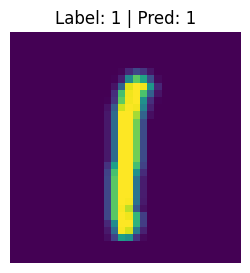

In [ ]:
# Testing sample predictions
sample_idx = random.randint(0, len(test_dataset)-1)
img, label = test_dataset[sample_idx]

model.eval()
with torch.inference_mode():
  logit = model(img.unsqueeze(dim=0).to(device))
  pred = torch.argmax(torch.softmax(logit, dim=1), dim=1)

plt.figure(figsize=(3,3))
plt.imshow(img.squeeze())
plt.axis("off")
plt.title(f"Label: {label} | Pred: {pred.item()}")
plt.show()